# ETE 1 — Iris classification with and without LDA

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Understand the raw data

Load Iris straight from `sklearn` as a DataFrame. Displaying the shape, the column types, the summary statistics and the class balance, because those four things decide most of the preprocessing that follows.

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

feature_names = list(iris.feature_names)
print("Shape:", df.shape)
print("Features:", feature_names)
print("Classes:", list(iris.target_names))
df.head()

Shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print(df.dtypes, "\n")
print("Class counts:\n", df["species"].value_counts(), "\n")
df[feature_names].describe().T

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object 

Class counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64 



,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


150 rows, 4 numeric features, 3 species with exactly 50 rows each. The classes are perfectly balanced, so plain accuracy is a fair headline metric here and we don't need class weights or resampling. Feature ranges differ though: sepal length spans 4.3–7.9 cm while petal width spans 0.1–2.5 cm, and the standard deviations differ by roughly 4x.

### Distributions per class

Histograms split by species tell us whether any single feature already separates the classes, which sets our expectation for how hard the classification problem is.

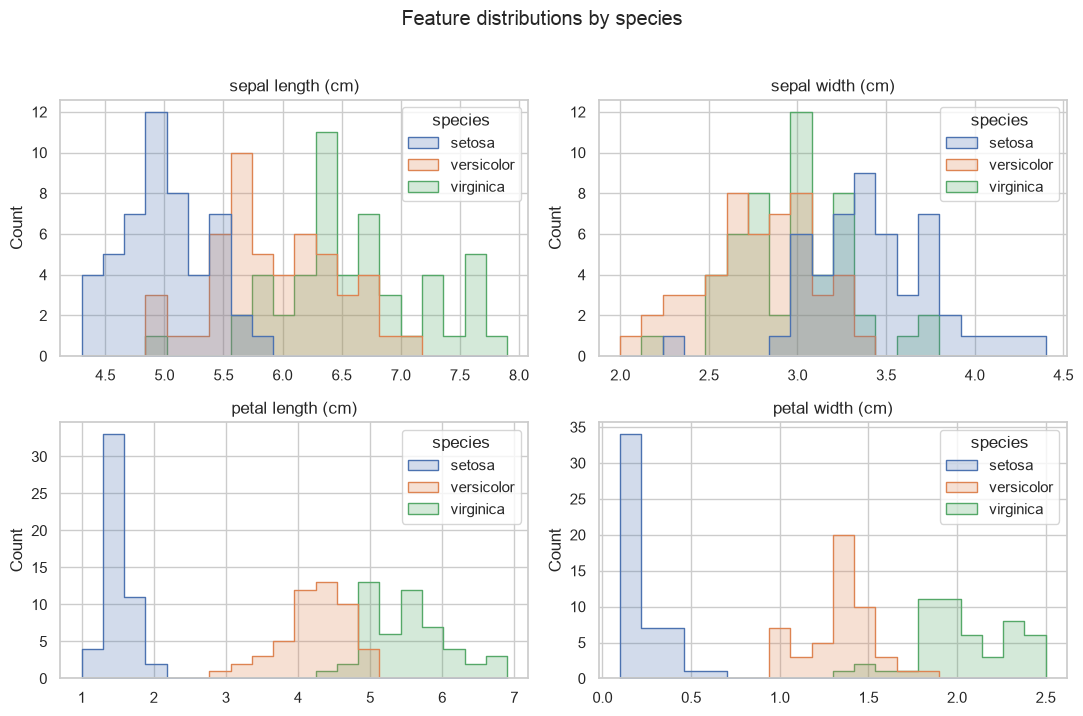

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), feature_names):
    sns.histplot(data=df, x=col, hue="species", element="step", bins=20, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Feature distributions by species", y=1.02)
plt.tight_layout()
plt.show()

Petal length and petal width separate setosa completely and leave only a small overlap between versicolor and virginica. The sepal features overlap far more, especially sepal width, which is close to a single bell curve for all three species. Each feature is roughly unimodal within a class, which matters later because LDA assumes each class is Gaussian.

### Outliers and spread

A boxplot per feature shows both the raw scale difference and any points far from the bulk of the data. The answer decides which scaler is appropriate.

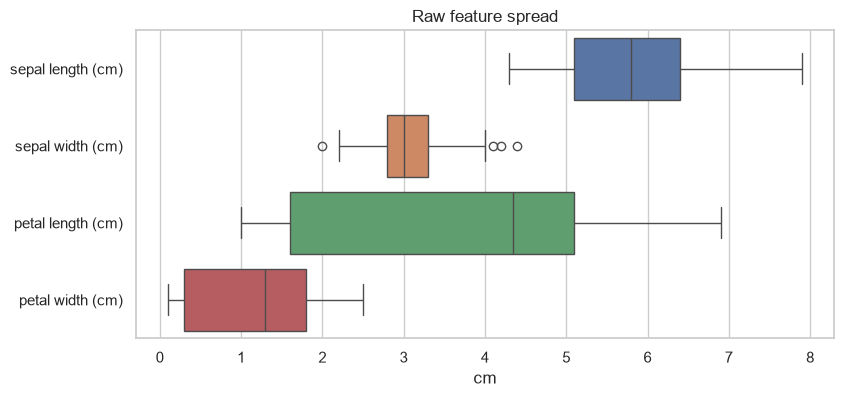

Points outside 1.5*IQR per feature:
 sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [5]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df[feature_names], orient="h")
plt.title("Raw feature spread")
plt.xlabel("cm")
plt.show()

q1, q3 = df[feature_names].quantile(0.25), df[feature_names].quantile(0.75)
iqr = q3 - q1
outliers = ((df[feature_names] < q1 - 1.5 * iqr) | (df[feature_names] > q3 + 1.5 * iqr)).sum()
print("Points outside 1.5*IQR per feature:\n", outliers)

Only sepal width has outliers by the 1.5x IQR rule, and there are 4 of them out of 150. That is too few to justify robust scaling, so a standard z-score is safe.

### Correlation between features

If two features carry nearly the same information, some of the 4 dimensions are wasted. That is the argument for dimensionality reduction, so it's worth checking before we build anything.

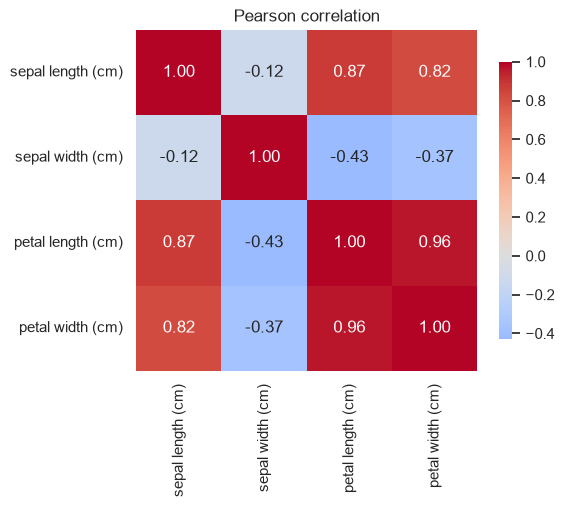

In [6]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(df[feature_names].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Pearson correlation")
plt.show()

Petal length and petal width correlate at 0.96, and both correlate above 0.8 with sepal length. Three of the four features move together almost as one, so the data really lives in fewer than 4 effective dimensions.

## 3. Missing values
The rule we follow: under 5% missing, drop the rows; 5–15%, impute (mode for categorical, and for numeric look at the distribution — mean if it is symmetric, median if it is skewed); above 15%, drop the column unless it is needed.

In [7]:
missing_pct = df[feature_names].isna().mean() * 100
print("Missing per feature (%):\n", missing_pct.round(2))
print("\nTotal missing cells:", int(df[feature_names].isna().sum().sum()))

Missing per feature (%):
 sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

Total missing cells: 0


Since there are no missing values, there is no need for imputation. 

## 4. Split, then scale

Split first and fit the scaler on the training set only, otherwise the test set's mean and variance leak into training. A 70/30 stratified split keeps 35 of each species in train and 15 in test.

Z-score standardisation is the right choice here: the features are continuous and roughly Gaussian, LDA assumes normality with a shared covariance, and KNN compares Euclidean distances that would otherwise be dominated by the widest-ranging feature.

Train: (105, 4)  Test: (45, 4)
Train class counts: [35 35 35]  Test: [15 15 15]


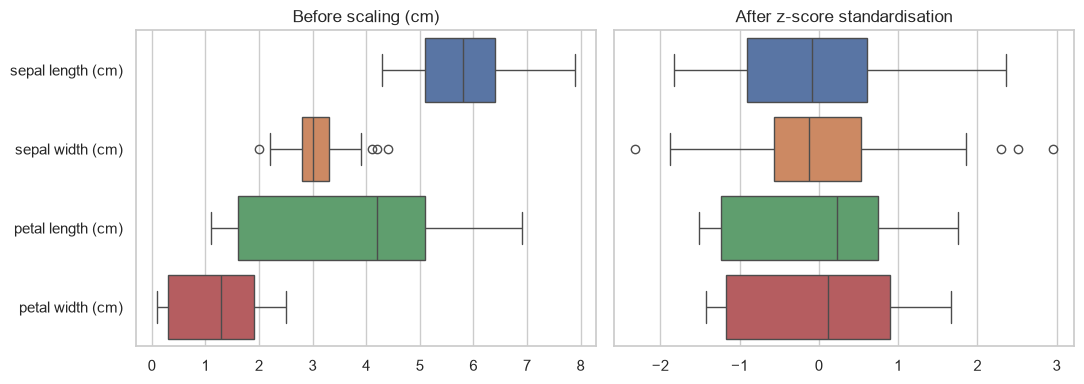

Train means after scaling: [ 0. -0. -0. -0.]
Train stds after scaling:  [1. 1. 1. 1.]


In [8]:
X = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class counts:", np.bincount(y_train), " Test:", np.bincount(y_test))

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
sns.boxplot(data=pd.DataFrame(X_train, columns=feature_names), orient="h", ax=axes[0])
axes[0].set_title("Before scaling (cm)")
sns.boxplot(data=pd.DataFrame(X_train_s, columns=feature_names), orient="h", ax=axes[1])
axes[1].set_title("After z-score standardisation")
axes[1].set_yticklabels([])
plt.tight_layout()
plt.show()

print("Train means after scaling:", np.round(X_train_s.mean(axis=0), 3))
print("Train stds after scaling: ", np.round(X_train_s.std(axis=0), 3))

Every feature now sits at mean 0 and standard deviation 1, so the four axes contribute equally to a distance calculation. The sepal width outliers remain.

## 5. Feature selection and extraction


Since there are only four features, we won't be performing any selection.

## 6. Pipeline A — original features

Baseline: standardise, then classify with KNN on all 4 features. KNN with Euclidean distance fits this data because the features are continuous and now on a common scale, and there are only 4 of them, so distances stay meaningful.

`k` is chosen by 5-fold stratified cross-validation on the training set, not on the test set. A small `k` chases noise and overfits; a large `k` smooths the boundary until classes blur.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_values = range(1, 26, 2)

def cv_curve(make_pipe):
    means, stds = [], []
    for k in k_values:
        scores = cross_val_score(make_pipe(k), X_train, y_train, cv=cv, scoring="accuracy")
        means.append(scores.mean()); stds.append(scores.std())
    return np.array(means), np.array(stds)

pipe_a = lambda k: Pipeline([("scale", StandardScaler()),
                             ("knn", KNeighborsClassifier(n_neighbors=k, metric="euclidean"))])

mean_a, std_a = cv_curve(pipe_a)
best_k_a = list(k_values)[int(np.argmax(mean_a))]
print(f"Pipeline A best k = {best_k_a}  (CV accuracy {mean_a.max():.4f})")

Pipeline A best k = 7  (CV accuracy 0.9619)


The scaler sits inside the `Pipeline`, so each CV fold refits it on that fold's training part only. That keeps the cross-validation estimate honest.

In [10]:
model_a = pipe_a(best_k_a).fit(X_train, y_train)
pred_a = model_a.predict(X_test)

acc_a = accuracy_score(y_test, pred_a)
print(f"Test accuracy: {acc_a:.4f}")
print(classification_report(y_test, pred_a, target_names=iris.target_names))

Test accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



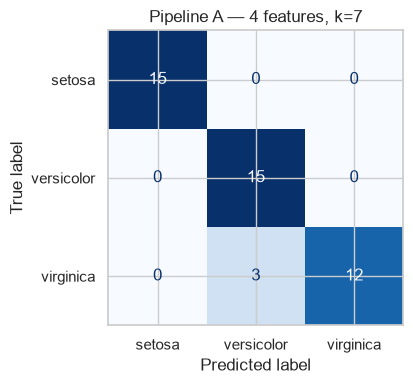

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_a),
                       display_labels=iris.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Pipeline A — 4 features, k={best_k_a}")
plt.tight_layout()
plt.show()

Pipeline A gets 93.3% on the held-out 45 rows. Every error is the same kind: three virginica flowers labelled versicolor, which pulls virginica recall down to 0.80 while its precision stays at 1.00. Setosa is never missed, matching the histograms where it sits well away from the other two on petal size.

### Decision boundary on the two strongest features

The 4-feature model cannot be drawn, so we refit the same KNN on petal length and petal width alone — the two features with the widest class separation — and plot its boundary. This is a slice through the real model, not the model itself, but it shows the shape KNN carves out when it works on raw measurements.

Accuracy using only these 2 features: 0.9111  (all 4 features: 0.9333)


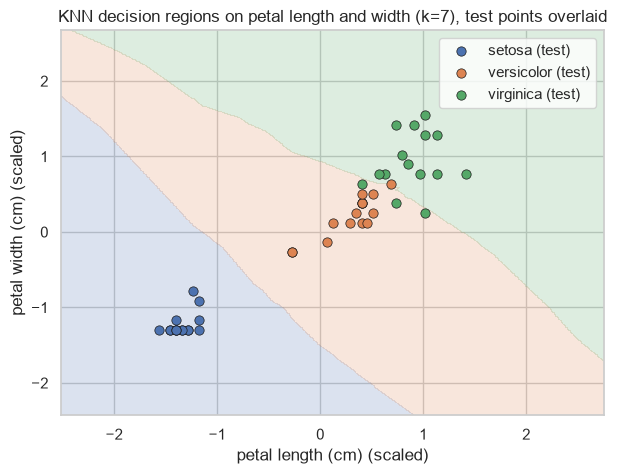

In [12]:
pair = ["petal length (cm)", "petal width (cm)"]
pair_idx = [feature_names.index(c) for c in pair]

scaler_pair = StandardScaler().fit(X_train[:, pair_idx])
P_train, P_test = scaler_pair.transform(X_train[:, pair_idx]), scaler_pair.transform(X_test[:, pair_idx])
knn_pair = KNeighborsClassifier(n_neighbors=best_k_a, metric="euclidean").fit(P_train, y_train)
print(f"Accuracy using only these 2 features: {knn_pair.score(P_test, y_test):.4f}  (all 4 features: {acc_a:.4f})")

x_min, x_max = P_train[:, 0].min() - 1, P_train[:, 0].max() + 1
y_min, y_max = P_train[:, 1].min() - 1, P_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
zz = knn_pair.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=["C0", "C1", "C2"])
for j, name in enumerate(iris.target_names):
    plt.scatter(*P_test[y_test == j].T, label=f"{name} (test)", s=45, edgecolor="k", linewidth=0.5)
plt.xlabel(f"{pair[0]} (scaled)"); plt.ylabel(f"{pair[1]} (scaled)")
plt.title(f"KNN decision regions on petal length and width (k={best_k_a}), test points overlaid")
plt.legend()
plt.show()

Setosa gets a clean region of its own, but the versicolor/virginica border is ragged and bends around individual training points, which is what KNN does when the two classes overlap in the input space. Dropping to these two features costs a little accuracy (91.1% against 93.3% on all four), so the other two features are still contributing.

## 7. Pipeline B — LDA then classify

LDA computes the within-class scatter `Sw` and between-class scatter `Sb`, then takes the eigenvectors of `Sw⁻¹Sb` that maximise the ratio of between to within. With 3 classes it can produce at most `n_classes - 1 = 2` discriminants, so 4 features collapse to 2 with the class labels steering the projection.

LDA is fit on the training set only and applied to the test set, same as the scaler.

Discriminants: 2
Between-class variance explained: [0.9882 0.0118]  total: 1.0


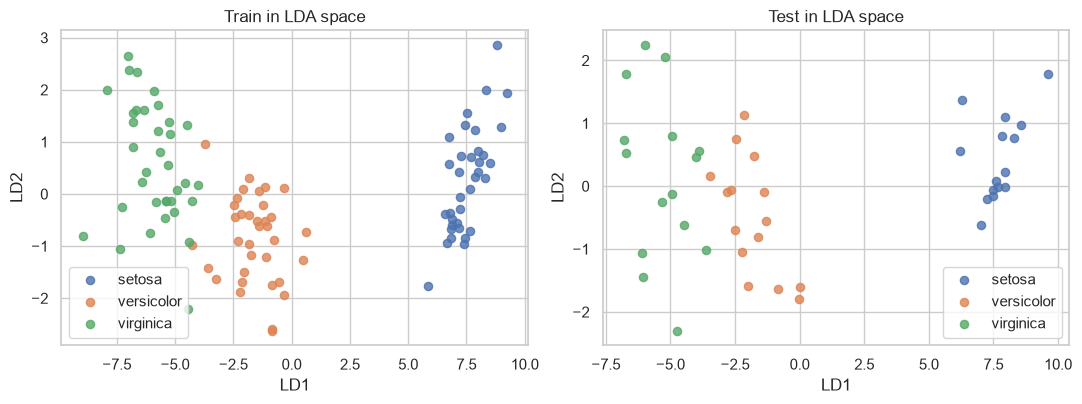

In [13]:
lda = LinearDiscriminantAnalysis(n_components=2).fit(X_train_s, y_train)
Z_train, Z_test = lda.transform(X_train_s), lda.transform(X_test_s)

evr = lda.explained_variance_ratio_
print("Discriminants:", Z_train.shape[1])
print("Between-class variance explained:", np.round(evr, 4), " total:", round(evr.sum(), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for i, name in enumerate(iris.target_names):
    axes[0].scatter(*Z_train[y_train == i].T, label=name, alpha=0.8, s=35)
    axes[1].scatter(*Z_test[y_test == i].T, label=name, alpha=0.8, s=35)
axes[0].set_title("Train in LDA space"); axes[1].set_title("Test in LDA space")
for ax in axes:
    ax.set_xlabel("LD1"); ax.set_ylabel("LD2"); ax.legend()
plt.tight_layout()
plt.show()

LD1 alone carries 98.8% of the between-class separation and splits all three species into visible bands; LD2 adds barely 1%. Setosa lands far to one side with a wide empty gap, while versicolor and virginica sit next to each other with a thin boundary between them. The test points fall in the same regions as the training points, so the projection generalises.

### Same classifier, reduced space

Everything is held constant except the LDA step, so any difference in score comes from the projection and not from a different model or a different `k`.

Pipeline B best k = 23  (CV accuracy 0.9905)


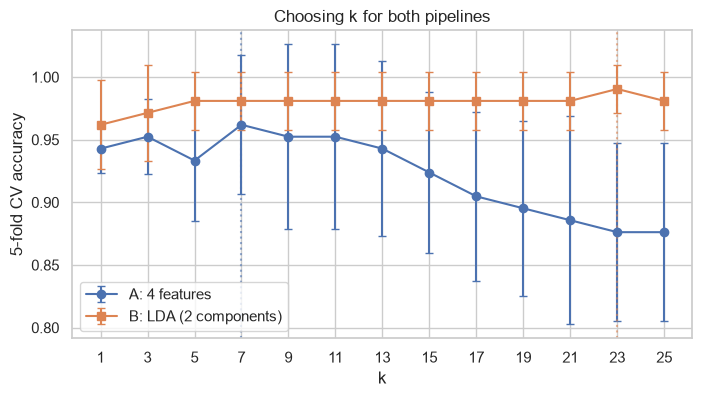

In [14]:
pipe_b = lambda k: Pipeline([("scale", StandardScaler()),
                             ("lda", LinearDiscriminantAnalysis(n_components=2)),
                             ("knn", KNeighborsClassifier(n_neighbors=k, metric="euclidean"))])

mean_b, std_b = cv_curve(pipe_b)
best_k_b = list(k_values)[int(np.argmax(mean_b))]
print(f"Pipeline B best k = {best_k_b}  (CV accuracy {mean_b.max():.4f})")

plt.figure(figsize=(8, 4))
ks = list(k_values)
plt.errorbar(ks, mean_a, yerr=std_a, marker="o", capsize=3, label="A: 4 features")
plt.errorbar(ks, mean_b, yerr=std_b, marker="s", capsize=3, label="B: LDA (2 components)")
plt.axvline(best_k_a, color="C0", ls=":", alpha=0.6)
plt.axvline(best_k_b, color="C1", ls=":", alpha=0.6)
plt.xlabel("k"); plt.ylabel("5-fold CV accuracy"); plt.title("Choosing k for both pipelines")
plt.xticks(ks); plt.legend()
plt.show()

Pipeline A peaks at k=7 and then decays past k~13, where the neighbourhood grows big enough to pull in the next species. Pipeline B holds around 0.98 for every k from 5 upward with a tighter spread between folds, so once the overlapping directions are gone the choice of k stops mattering much - its win at k=23 is worth about one extra correct fold.

In [15]:
model_b = pipe_b(best_k_b).fit(X_train, y_train)
pred_b = model_b.predict(X_test)

acc_b = accuracy_score(y_test, pred_b)
print(f"Test accuracy: {acc_b:.4f}")
print(classification_report(y_test, pred_b, target_names=iris.target_names))

Test accuracy: 0.9778
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



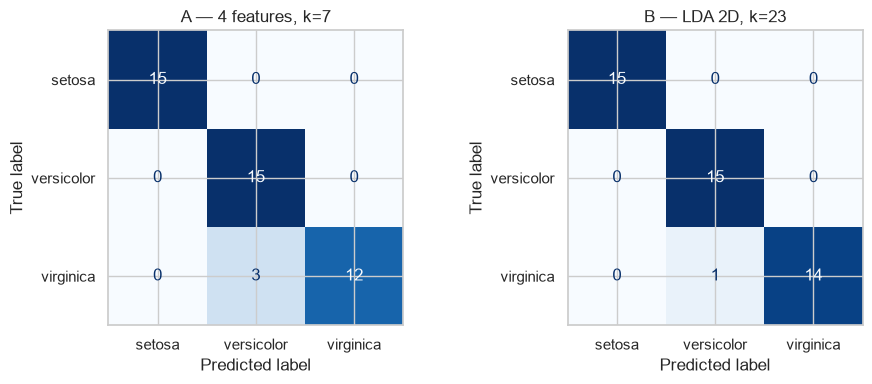

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, (pred, title) in zip(axes, [(pred_a, f"A — 4 features, k={best_k_a}"),
                                    (pred_b, f"B — LDA 2D, k={best_k_b}")]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=iris.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

Pipeline B gets 97.8% with one error, again a virginica read as versicolor. Both pipelines make the same kind of mistake; LDA just makes fewer of them, because the projection has already thrown away the directions where versicolor and virginica bleed into each other.

### Decision boundary in the reduced space

A 2D space can be drawn in full, which the original 4D space cannot. This is a practical side benefit of the reduction: the model becomes inspectable.

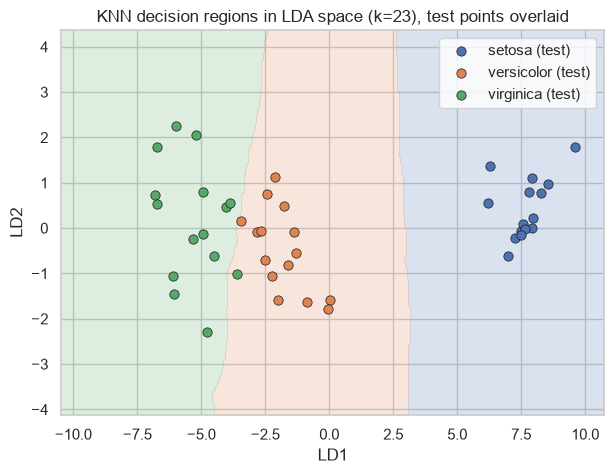

In [17]:
knn_2d = KNeighborsClassifier(n_neighbors=best_k_b, metric="euclidean").fit(Z_train, y_train)
x_min, x_max = Z_train[:, 0].min() - 1.5, Z_train[:, 0].max() + 1.5
y_min, y_max = Z_train[:, 1].min() - 1.5, Z_train[:, 1].max() + 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
zz = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=["C0", "C1", "C2"])
for i, name in enumerate(iris.target_names):
    plt.scatter(*Z_test[y_test == i].T, label=f"{name} (test)", s=45, edgecolor="k", linewidth=0.5)
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.title(f"KNN decision regions in LDA space (k={best_k_b}), test points overlaid")
plt.legend()
plt.show()

The setosa region is separated by a wide empty margin, and the versicolor/virginica boundary is close to a vertical line on LD1. The single test error sits right against that line, which is the only place in this space where a mistake is plausible.

## 8. Comparison

Test-set scores answer "which is more accurate" and the cross-validated scores answer "is the difference stable rather than an artefact of one lucky split".

In [18]:
def scores(y_true, pred):
    return {"accuracy": accuracy_score(y_true, pred),
            "precision (macro)": precision_score(y_true, pred, average="macro"),
            "recall (macro)": recall_score(y_true, pred, average="macro"),
            "f1 (macro)": f1_score(y_true, pred, average="macro")}

cv_a = cross_val_score(pipe_a(best_k_a), X_train, y_train, cv=cv, scoring="accuracy")
cv_b = cross_val_score(pipe_b(best_k_b), X_train, y_train, cv=cv, scoring="accuracy")

comparison = pd.DataFrame({"A: original 4 features": scores(y_test, pred_a),
                           "B: LDA 2 components": scores(y_test, pred_b)}).T
comparison["CV accuracy (mean)"] = [cv_a.mean(), cv_b.mean()]
comparison["CV accuracy (std)"] = [cv_a.std(), cv_b.std()]
comparison["dimensions"] = [X_train.shape[1], 2]
comparison.round(4)

,accuracy,precision (macro),recall (macro),f1 (macro),CV accuracy (mean),CV accuracy (std),dimensions
A: original 4 features,0.9333,0.9444,0.9333,0.9327,0.9619,0.0555,4
B: LDA 2 components,0.9778,0.9792,0.9778,0.9778,0.9905,0.0190,2


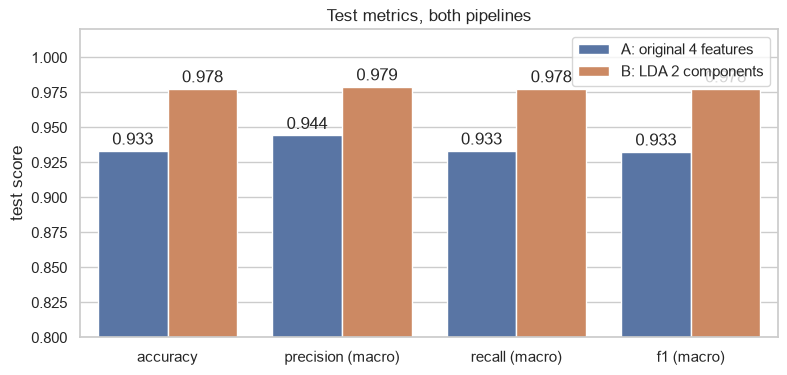

In [19]:
metrics = ["accuracy", "precision (macro)", "recall (macro)", "f1 (macro)"]
plot_df = comparison[metrics].reset_index().melt(id_vars="index", var_name="metric", value_name="score")

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=plot_df, x="metric", y="score", hue="index")
ax.set_ylim(0.8, 1.02)
ax.set_xlabel(""); ax.set_ylabel("test score"); ax.legend(title="")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2)
plt.title("Test metrics, both pipelines")
plt.show()

### Computational cost

- KNN measures the distance from every test point to every training point, so the work per distance is proportional to the number of features: 2 coordinates instead of 4 is half the arithmetic, and the projection itself is one small matrix multiply done once.
- Pipeline B also stores half as many numbers per sample, and that gap widens with the original feature count — LDA always ends at `n_classes - 1` dimensions regardless of how wide the input was.

## 9. Inferences

- Iris is clean: 150 rows, 4 numeric features, no missing values, and 50 rows per species, so no imputation branch ran and accuracy is a fair headline metric.
- Z-score standardisation was the right scaler: the features are near-Gaussian with only 4 mild outliers in sepal width, and both LDA and Euclidean KNN assume comparable scales.
- Splitting before scaling, and keeping the scaler and LDA inside the `Pipeline`, stops test-set statistics from leaking into training or into the CV estimate.
- LDA compressed 4 features into 2 discriminants, and LD1 alone holds 98.8% of the between-class separation.
- The LDA pipeline beat the raw-feature pipeline on the test set (97.8% vs 93.3%) and in cross-validation (0.99 vs 0.96 mean accuracy, with about a third of the fold-to-fold spread).
- Every error in both pipelines is a virginica called versicolor; setosa is classified perfectly either way, which is what the raw distributions predicted.
- Pipeline A's accuracy falls away past k of about 13 while Pipeline B stays flat across the whole range, so the reduced features is far less sensitive to how k is picked.
- LDA adds no information - it drops the directions where the classes overlap, and accuracy improves because the discarded noise is no longer distorting the distances KNN relies on.
- The LDA space can be plotted in full, so its boundary is the real one; Pipeline A's boundary can only be seen through a 2-feature slice, which loses accuracy (91.1% against 93.3%).
- Halving the dimensions halves the arithmetic in every KNN distance calculation and the memory per stored sample, and LDA caps the output at `n_classes - 1` dimensions no matter how wide the input is.
- For Iris the practical case for LDA is the cleaner boundary and the stability across k; on wide data the same step also cuts neighbour-search cost and the sparsity that hurts distance-based classifiers.